In [9]:
full_path_where_plotstyle_directory_is_located = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/plottemplate-master/low_rad_plot_style'
import sys
sys.path.append(full_path_where_plotstyle_directory_is_located)

import LowRadPlotStyle as xps
xps.use('lowrad')

In [37]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


from iminuit import Minuit
from iminuit.cost import LeastSquares
import iminuit

from uncertainties import ufloat, unumpy

***
# Energy distribution

In [1]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "EnergyDist" 
path_length = "Rock"


min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

NameError: name 'glob' is not defined

In [5]:
num = 1
uproot_files = uproot_files[:num]

In [6]:
arr = uproot.dask(uproot_files, filter_name=uproot.open(uproot_files[0]).keys(), allow_missing=True, step_size="1100MB")
arr['type_pri_id'] = ak.flatten(arr['type_pri_id'])

arr = arr[arr['type_pri_id'] == 2112]
arr


dask.awkward<getitem, npartitions=5>

In [7]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [8]:
data_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data'
if not os.path.exists(f'{data_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{data_path}/{path_Version}/{path_Material}/{path_length}')

FORCE_OVERWRITE = False

## Meta-Daten und Tabellen für IDs

In [9]:
file = data_files[0]  # Use the first file for demonstration
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

The file contains 23 keys:
  G4VERSION_TAG;1
  MC_TAG;1
  MCVERSION_TAG;1
  macros;1
  macros/preinit.mac;1
  macros/det_setup.mac;1
  macros/src_neutron.mac;1
  tables;1
  tables/neutronXS_G4_AIR;1
  tables/neutronXS_G4_WATER;1
  tables/neutronXS_G4_Galactic;1
  tables/neutronXS_LXe;1
  tables/neutronXS_LXe_nA;1
  tables/neutronXS_Rock;1
  tables/neutronXS_Concrete;1
  tables/neutronXS_SS304LSteel;1
  tables/process_subtypes;1
  tables/logical_volumes;1
  tables/physical_volumes;1
  events;1
  events/nbevents;1
  events/events;1
  G4RUNTIME;1

Executed with G4VERSION $Name: geant4-10-06-patch-02 $
Total runtime: 58487.416933796 seconds
Number of events: 4000000

Using the macros:
--> preinit.mac
    File content hidden for brevity ...
    # ./macros/EnergyDistributionRock/preinit.mac
    
    /control/verbose 0
    /run/verbose 0
    /event/verbose 0
    /tracking/verbose 0
    
    # select how would you like to simulate radioactive decays
    # setting 0 means that you would like to

In [10]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [11]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [12]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## Energy Distributions trend

In [173]:
df_pri = da.to_dataframe(arr[['e_pri']])
df = da.to_dataframe(arr[['Save_desc', 'Save_e', 'Save_volume']])

In [174]:
# Jetzt verwende die Hashes direkt im Dask DataFrame (KEINE STRING-VERGLEICHE!)
labels = ['e_pri','Rock (not Spawn)', 'Concrete', 'Detector']

# Verwende nur noch Hash-Vergleiche - viel schneller!
arrays = [df_pri['e_pri']]
arrays += [df[(df['Save_desc'] == 'RockPhysicalVolume') & 
              (df['Save_volume'] == 'RockSpawnPhysicalVolume')]['Save_e']]
arrays += [df[df['Save_desc'].isin(['ConcretePhysicalVolume', 'ConcreteSpawnPhysicalVolume'])]['Save_e']]
arrays += [df[df['Save_desc'] == 'CountPhysicalVolume']['Save_e']]

In [175]:
hist_tasks = []
bins = []

#log_bins = np.logspace(np.log10(5), np.log10(10000), 251)  # 1 keV bis 10000 keV, 100 Bins
log_bins = np.linspace(0, 10000, 250)

for i in range(len(arrays)):
    hist_task, bin_edges = dh.histogram(arrays[i], bins=log_bins)
    hist_tasks.append(hist_task)
    bins.append(bin_edges)


In [176]:
with ProgressBar():
    hist_vals_list = [a.compute() for a in hist_tasks]
    bin_edges_list = [b.compute() for b in bins]


[########################################] | 100% Completed | 7.98 ss
[########################################] | 100% Completed | 8.46 ss
[########################################] | 100% Completed | 6.35 ss
[########################################] | 100% Completed | 6.47 ss
[########################################] | 100% Completed | 101.32 ms
[########################################] | 100% Completed | 101.23 ms
[########################################] | 100% Completed | 101.43 ms
[########################################] | 100% Completed | 101.24 ms


In [177]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes_log.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            hist_vals_list=hist_vals_list, 
            bin_edges_list=bin_edges_list,
            labels=labels)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Datei bereits vorhanden, überspringe: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Rock/EnergyDistributions_Volumes_log.npz


1
0
2
3


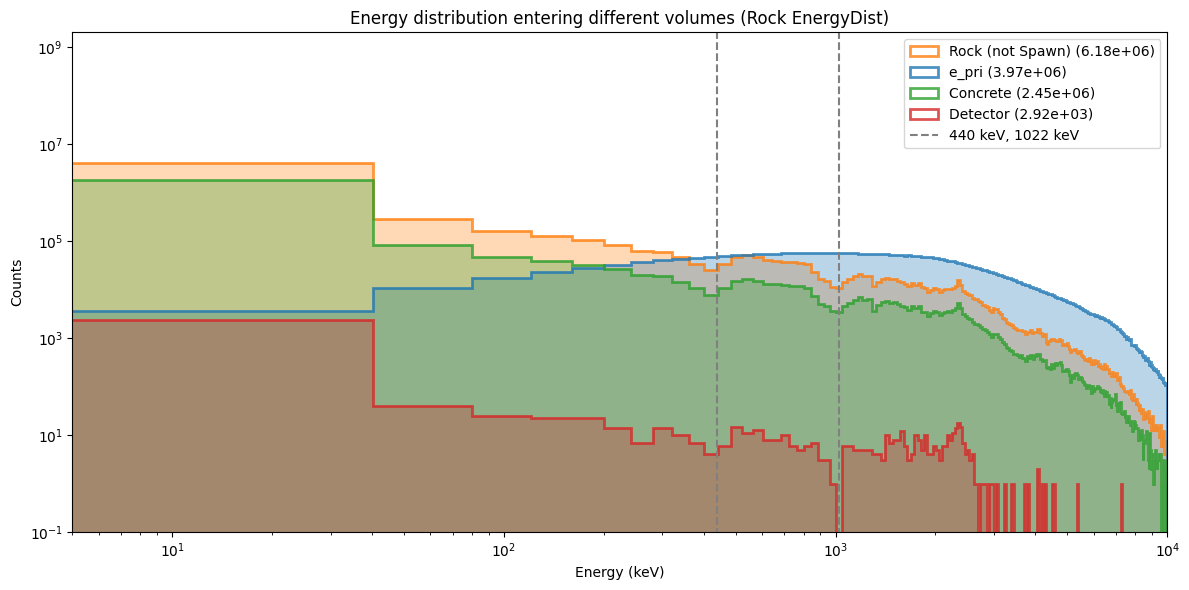

In [178]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)



for i in all_indices_sorted:
    print(i)

    # Use bar_edge_color safely
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='step', linewidth=2, color=colors[i],
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})', alpha=0.8)
    
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='stepfilled', color=colors[i], alpha=0.3)

plt.vlines([440,1022], 0, 2e9, colors='grey', linestyles='--', label='440 keV, 1022 keV')
plt.yscale('log')
plt.xscale('log')
plt.xlim(5, 10000)
plt.ylim(0.1,2e9)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.show()

# Loading the data for energy distribution


In [61]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "EnergyDist" 
path_length = "Rock"


min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 250 files matching pattern 'Rock' in '/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/EnergyDist/Rock/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [62]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Concrete/EnergyDistributions_Volumes_log.npz"
hist_vals_list_c_log = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_c_log = np.load(path, allow_pickle=True)['bin_edges_list']
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Rock/EnergyDistributions_Volumes_log.npz"
hist_vals_list_r_log = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_r_log = np.load(path, allow_pickle=True)['bin_edges_list']

path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Concrete/EnergyDistributions_Volumes_lin.npz"
hist_vals_list_c_lin = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_c_lin = np.load(path, allow_pickle=True)['bin_edges_list']
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Rock/EnergyDistributions_Volumes_lin.npz"
hist_vals_list_r_lin = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_r_lin = np.load(path, allow_pickle=True)['bin_edges_list']

/tmp/ipykernel_21661/3052881052.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


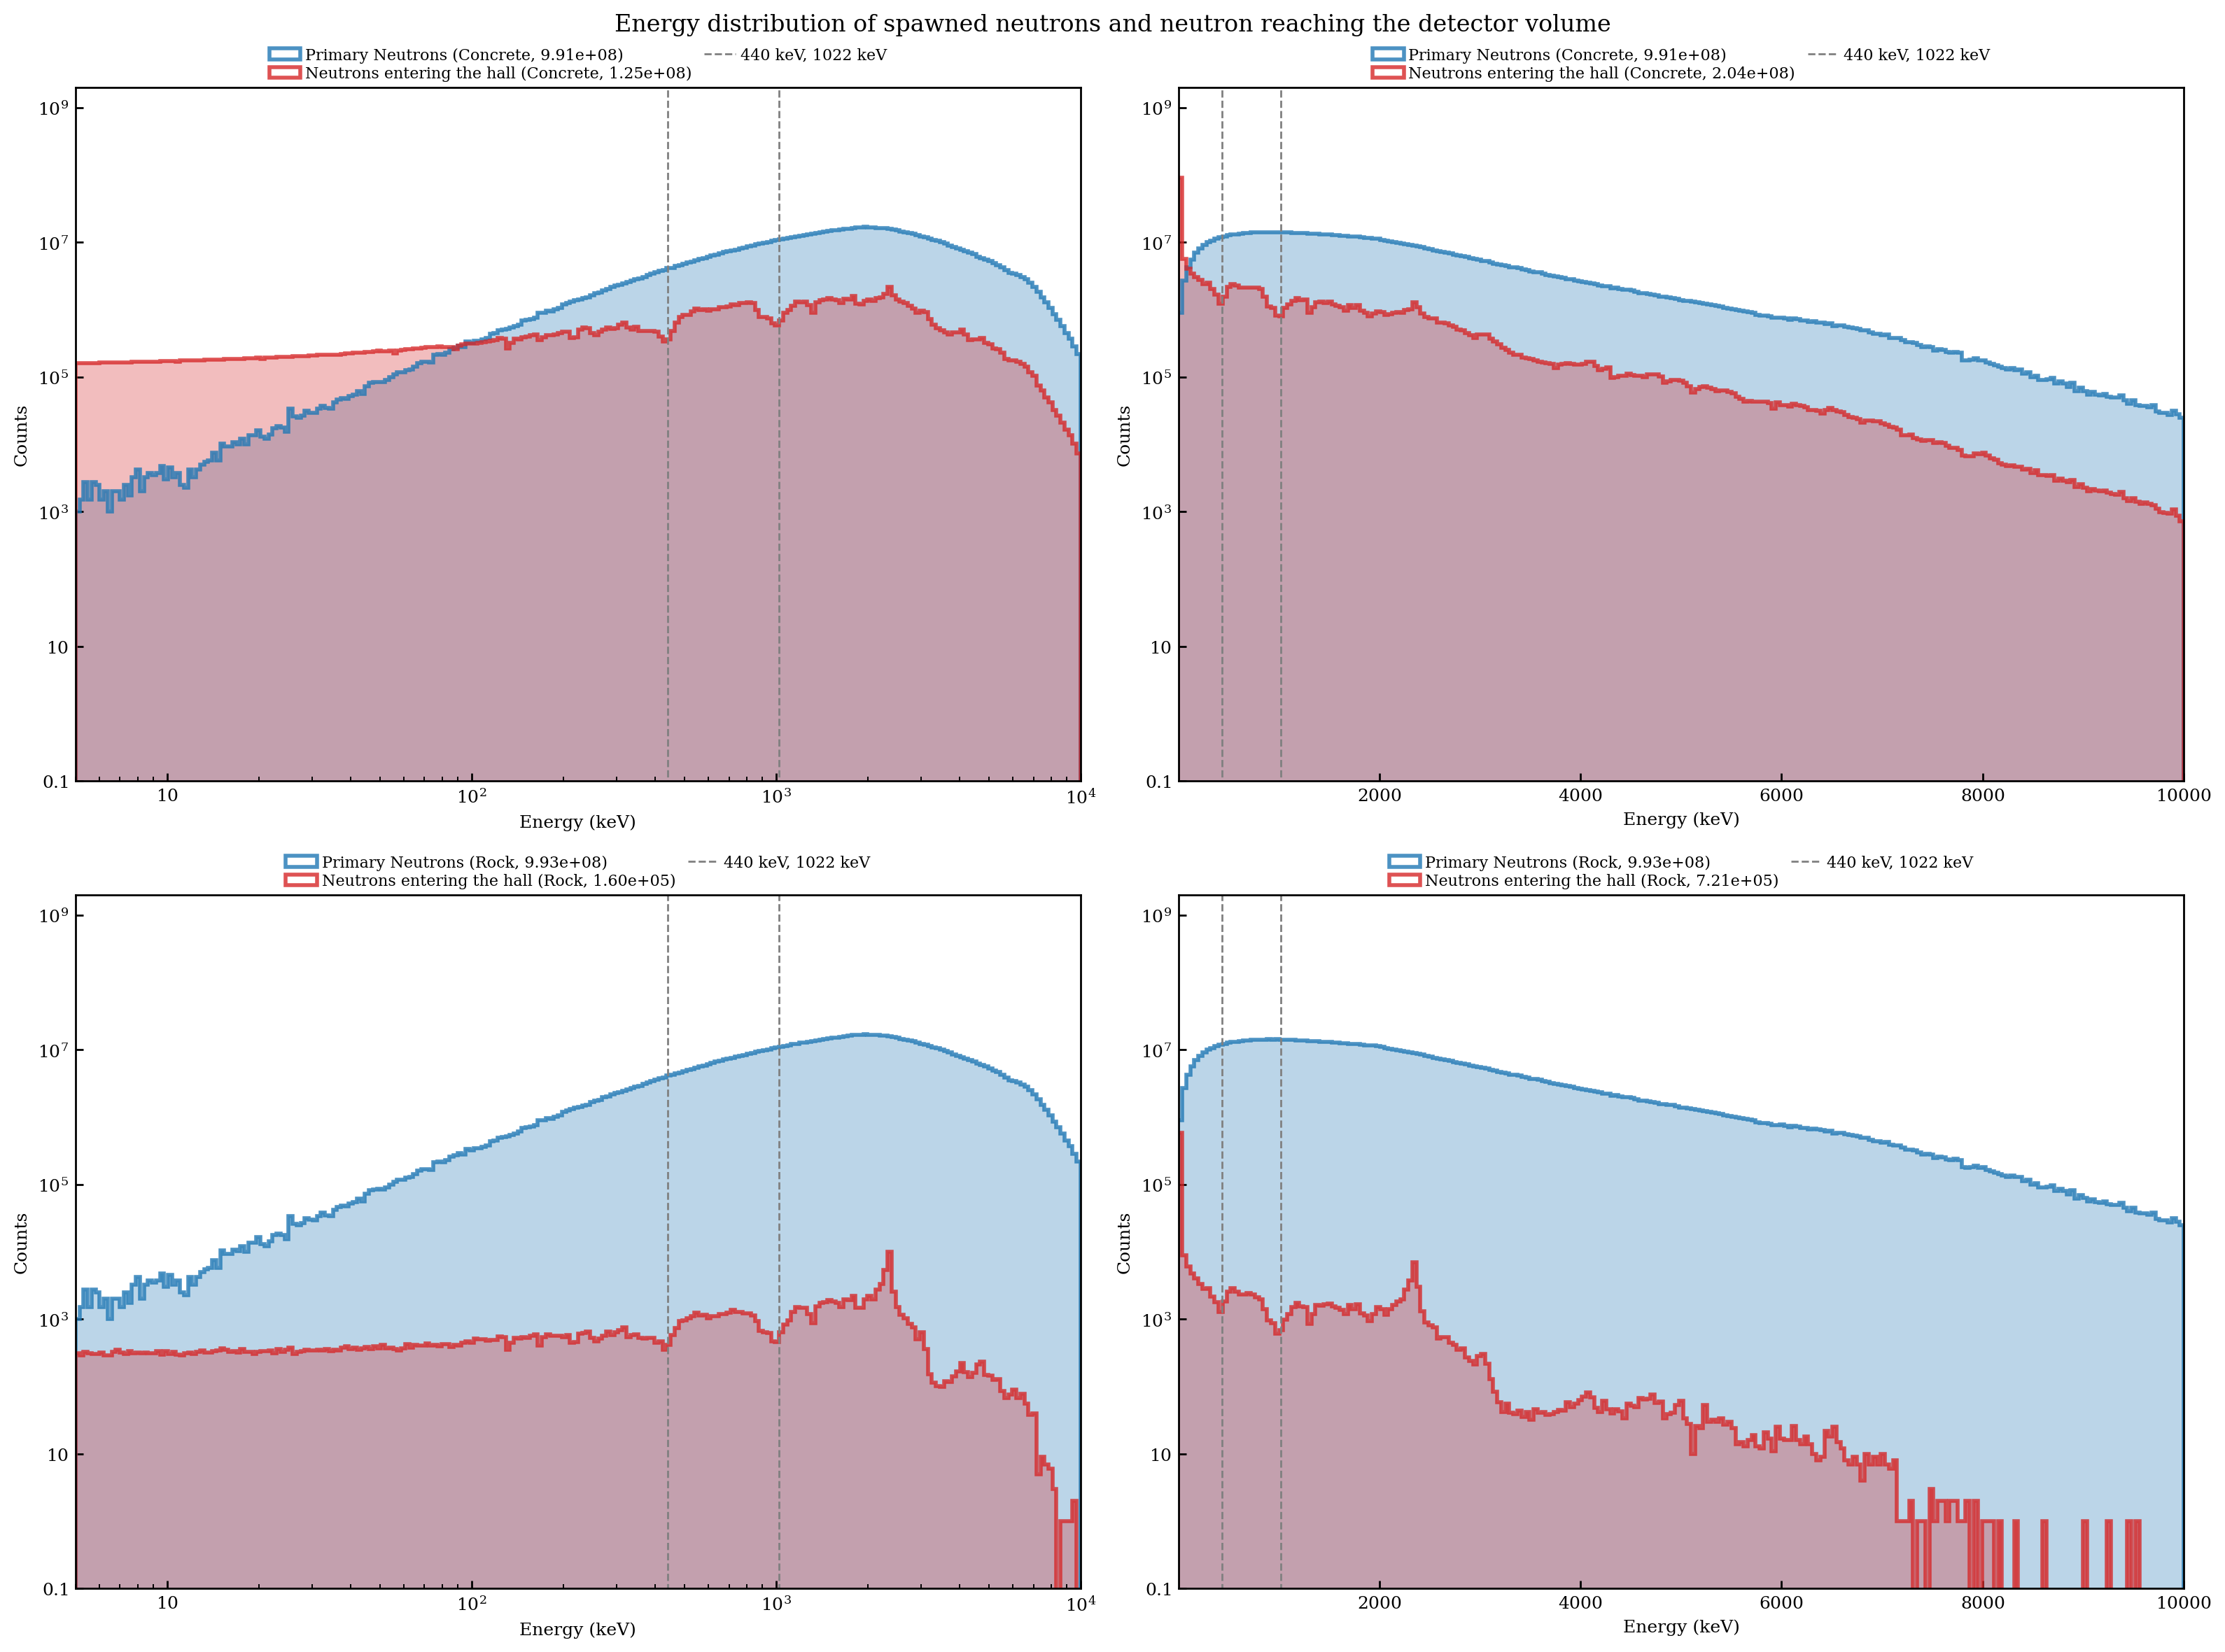

In [63]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Increased height for clarity

vals_data = [[hist_vals_list_c_log[0], hist_vals_list_c_log[3]], 
             [hist_vals_list_c_lin[0], hist_vals_list_c_lin[3]],
             [hist_vals_list_r_log[0], hist_vals_list_r_log[3]],
             [hist_vals_list_r_lin[0], hist_vals_list_r_lin[3]]]
bin_data = [[bin_edges_list_c_log[0], bin_edges_list_c_log[3]], 
            [bin_edges_list_c_lin[0], bin_edges_list_c_lin[3]],
            [bin_edges_list_r_log[0], bin_edges_list_r_log[3]],
            [bin_edges_list_r_lin[0], bin_edges_list_r_lin[3]]]
labels = ['Primary Neutrons', 'Neutrons entering the hall']
elements = ['Concrete','Concrete', 'Rock', 'Rock']

axs_flat = axs.flat  # Flatten the 2D array of axes

for i in range(len(vals_data)):
    ax = next(axs_flat)
    ax.hist(bin_data[i][0][:-1], bins=bin_data[i][0], weights=vals_data[i][0],
            histtype='step', linewidth=2, color=colors[0],
            label=f'{labels[0]} ({elements[i]}, {sum(vals_data[i][0]):.2e})', alpha=0.8)
    ax.hist(bin_data[i][0][:-1], bins=bin_data[i][0], weights=vals_data[i][0],
            histtype='stepfilled', color=colors[0], alpha=0.3)

    ax.hist(bin_data[i][1][:-1], bins=bin_data[i][1], weights=vals_data[i][1],
            histtype='step', linewidth=2, color=colors[3],
            label=f'{labels[1]} ({elements[i]}, {sum(vals_data[i][1]):.2e})', alpha=0.8)
    ax.hist(bin_data[i][1][:-1], bins=bin_data[i][1], weights=vals_data[i][1],
            histtype='stepfilled', color=colors[3], alpha=0.3)

    ax.vlines([440,1022], 0, 2e9, colors='grey', linestyles='--', label='440 keV, 1022 keV')
    ax.set_yscale('log')
    ax.set_xscale('log') if i%2 == 0 else ax.set_xscale('linear')
    ax.set_xlim(5, 10000)
    ax.set_ylim(0.1, 2e9)
    ax.set_xlabel('Energy (keV)')
    ax.set_ylabel('Counts')
    ax.legend()

# Hide any unused subplots
for j in range(len(vals_data), len(axs.flat)):
    axs.flat[j].set_visible(False)

plt.suptitle(f'Energy distribution of spawned neutrons and neutron reaching the detector volume')
plt.tight_layout()
plt.show()

/tmp/ipykernel_21661/2926449694.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


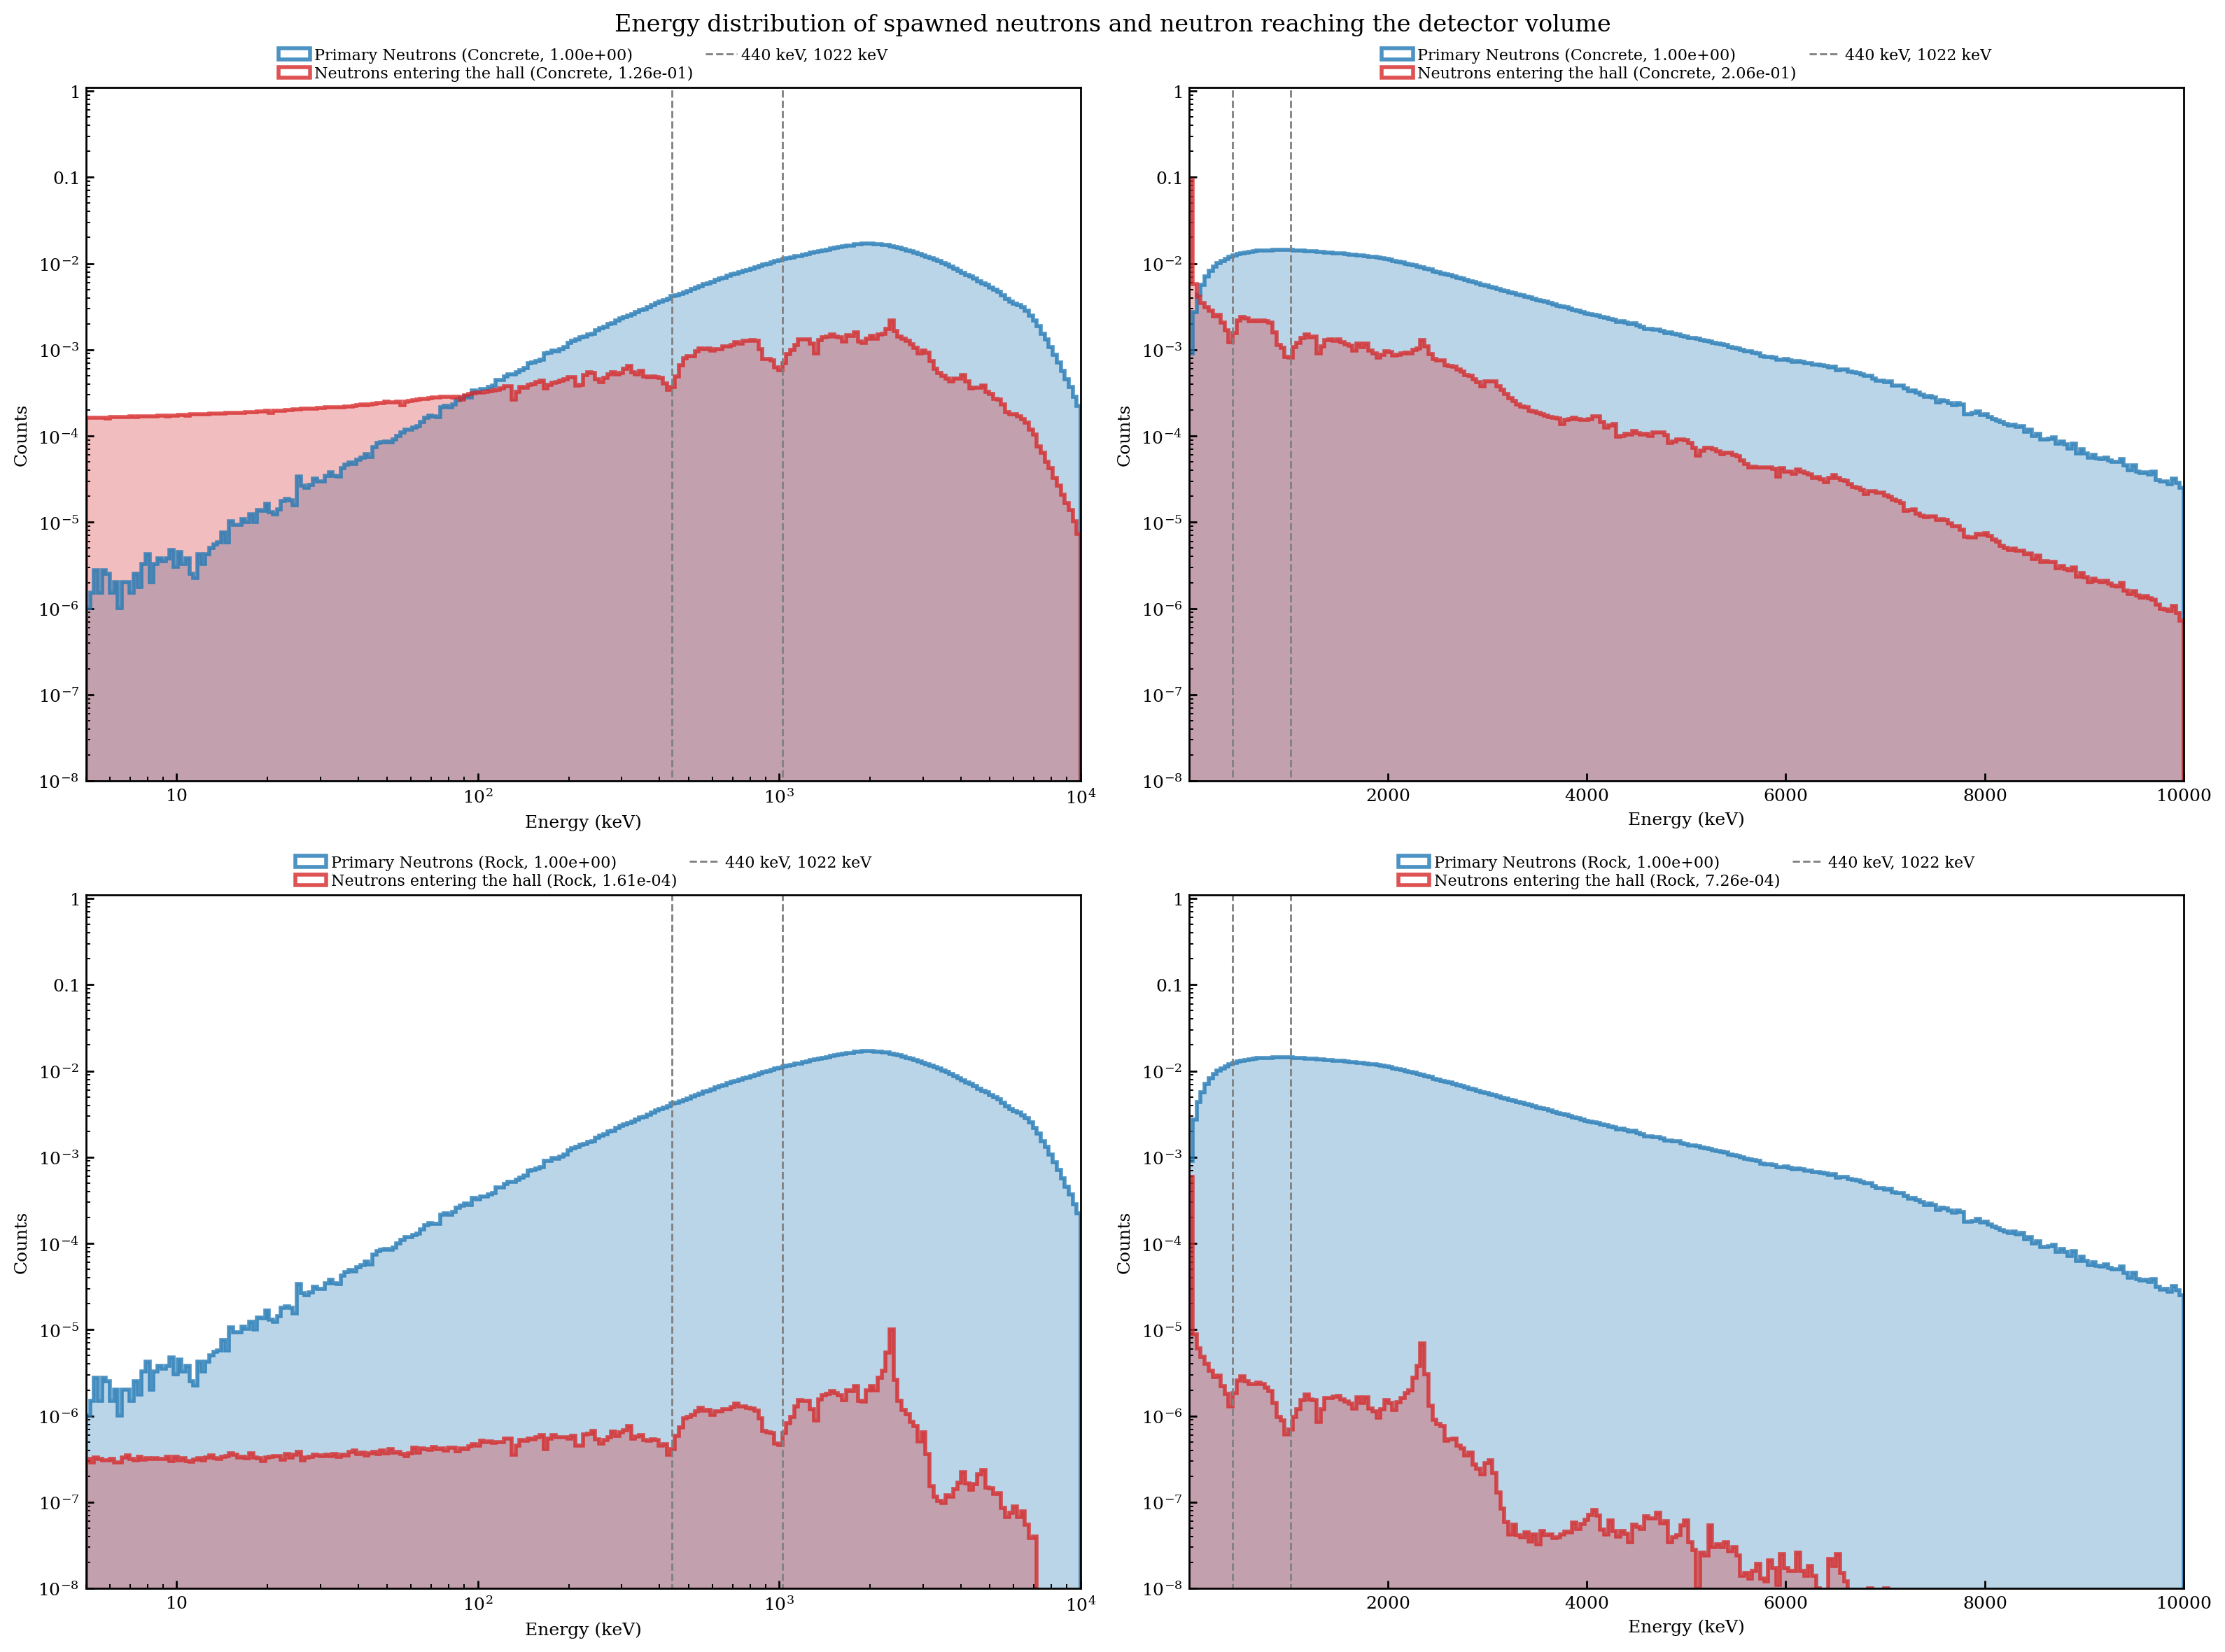

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))  # Increased height for clarity

norm_rock = sum(hist_vals_list_r_lin[0]) 
norm_concrete = sum(hist_vals_list_c_lin[0])

vals_data_norm = [[hist_vals_list_c_log[0]/norm_concrete, hist_vals_list_c_log[3]/norm_concrete], 
             [hist_vals_list_c_lin[0]/norm_concrete, hist_vals_list_c_lin[3]/norm_concrete],
             [hist_vals_list_r_log[0]/norm_rock, hist_vals_list_r_log[3]/norm_rock],
             [hist_vals_list_r_lin[0]/norm_rock, hist_vals_list_r_lin[3]/norm_rock]]
bin_data_norm = [[bin_edges_list_c_log[0], bin_edges_list_c_log[3]], 
            [bin_edges_list_c_lin[0], bin_edges_list_c_lin[3]],
            [bin_edges_list_r_log[0], bin_edges_list_r_log[3]],
            [bin_edges_list_r_lin[0], bin_edges_list_r_lin[3]]]
labels = ['Primary Neutrons', 'Neutrons entering the hall']
elements = ['Concrete','Concrete', 'Rock', 'Rock']

axs_flat = axs.flat  # Flatten the 2D array of axes

for i in range(len(vals_data)):
    ax = next(axs_flat)
    ax.hist(bin_data_norm[i][0][:-1], bins=bin_data_norm[i][0], weights=vals_data_norm[i][0],
            histtype='step', linewidth=2, color=colors[0],
            label=f'{labels[0]} ({elements[i]}, {sum(vals_data_norm[i][0]):.2e})', alpha=0.8)
    ax.hist(bin_data_norm[i][0][:-1], bins=bin_data_norm[i][0], weights=vals_data_norm[i][0],
            histtype='stepfilled', color=colors[0], alpha=0.3)

    ax.hist(bin_data_norm[i][1][:-1], bins=bin_data_norm[i][1], weights=vals_data_norm[i][1],
            histtype='step', linewidth=2, color=colors[3],
            label=f'{labels[1]} ({elements[i]}, {sum(vals_data_norm[i][1]):.2e})', alpha=0.8)
    ax.hist(bin_data_norm[i][1][:-1], bins=bin_data_norm[i][1], weights=vals_data_norm[i][1],
            histtype='stepfilled', color=colors[3], alpha=0.3)

    ax.vlines([440,1022], 0, 2e9, colors='grey', linestyles='--', label='440 keV, 1022 keV')
    ax.set_yscale('log')
    ax.set_xscale('log') if i%2 == 0 else ax.set_xscale('linear')
    ax.set_xlim(5, 10000)
    ax.set_ylim(1e-8, 1.1)
    ax.set_xlabel('Energy (keV)')
    ax.set_ylabel('Counts')
    ax.legend()

# Hide any unused subplots
for j in range(len(vals_data), len(axs.flat)):
    axs.flat[j].set_visible(False)

plt.suptitle(f'Energy distribution of spawned neutrons and neutron reaching the detector volume')
plt.tight_layout()
plt.show()

In [65]:
vals_data_comb = [[1/3*vals_data_norm[0][0] + 2/3 * vals_data_norm[2][0],   #log prim
                  1/3*vals_data_norm[0][1] + 2/3 * vals_data_norm[2][1]],   #log neutrons
                  [1/3*vals_data_norm[1][0] + 2/3 * vals_data_norm[3][0],   #lin prim
                   1/3*vals_data_norm[1][1] + 2/3 * vals_data_norm[3][1]]]  #lin neutrons

bin_data_comb = [[bin_data_norm[0][0], bin_data_norm[0][1]], 
                 [bin_data_norm[1][0], bin_data_norm[1][1]]]

In [66]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/probabilities.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            prob = vals_data_comb[1][1], 
            bin_data = bin_data_comb[1][1])
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Datei bereits vorhanden, überspringe: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/probabilities.npz


/tmp/ipykernel_21661/3287627962.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


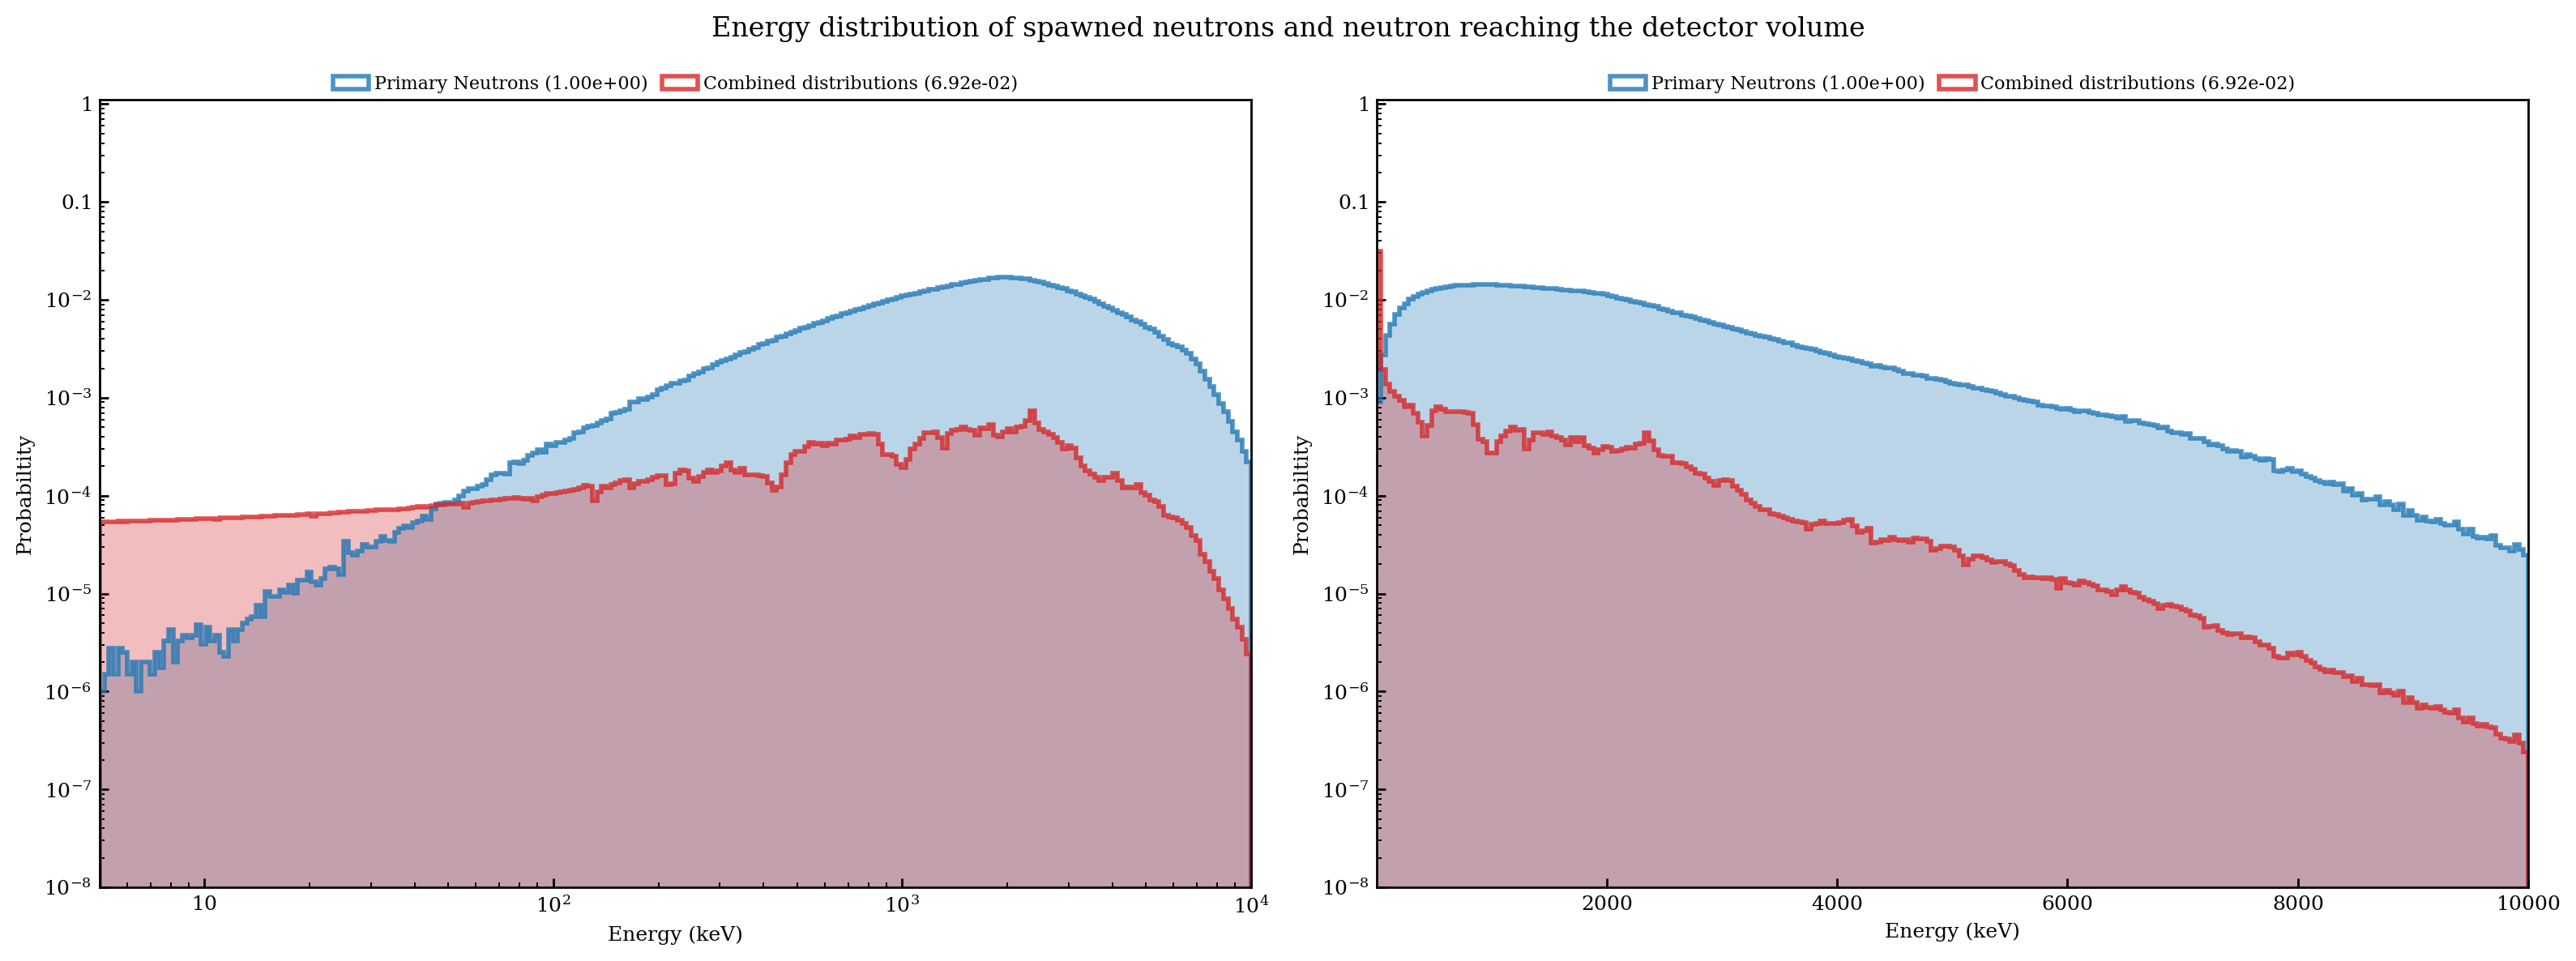

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # Increased height for clarity


labels = ['Primary Neutrons', 'Combined distributions']

axs_flat = axs.flat  # Flatten the 2D array of axes

for i in range(len(axs_flat)):
    ax = axs_flat[i]
    ax.hist(bin_data_comb[i][0][:-1], bins=bin_data_comb[i][0], weights=vals_data_comb[i][0],
            histtype='step', linewidth=2, color=colors[0],
            label=f'{labels[0]} ({sum(vals_data_comb[i][0]):.2e})', alpha=0.8)
    ax.hist(bin_data_comb[i][0][:-1], bins=bin_data_comb[i][0], weights=vals_data_comb[i][0],
            histtype='stepfilled', color=colors[0], alpha=0.3)

    ax.hist(bin_data_comb[i][1][:-1], bins=bin_data_comb[i][1], weights=vals_data_comb[i][1],
            histtype='step', linewidth=2, color=colors[3],
            label=f'{labels[1]} ({sum(vals_data_comb[1][1]):.2e})', alpha=0.8)
    ax.hist(bin_data_comb[i][1][:-1], bins=bin_data_comb[i][1], weights=vals_data_comb[i][1],
            histtype='stepfilled', color=colors[3], alpha=0.3)
    
    #ax.plot(used_rate[:,0], used_rate[:,1], color='black', linestyle='--', label='Radiogenic Neutron Distribution')
    ax.set_yscale('log')
    ax.set_xscale('log') if i%2 == 0 else ax.set_xscale('linear')
    ax.set_xlim(5, 10000)
    ax.set_ylim(1e-8, 1.1)
    ax.set_xlabel('Energy (keV)')
    ax.set_ylabel('Probabiltity')
    ax.legend()

# Hide any unused subplots
for j in range(len(axs_flat), len(axs.flat)):
    axs.flat[j].set_visible(False)

plt.suptitle(f'Energy distribution of spawned neutrons and neutron reaching the detector volume')
plt.tight_layout()
plt.show()

In [68]:
used_rate = np.loadtxt('/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/RadiogenicNeutronDistribution.txt', skiprows=2)

v_rock = 1* 1* 1 * 1e6
v_concrete = 1* 1* 0.5 * 1e6

R0 = 137.375 * sum(used_rate[:,1])
rate = vals_data_comb[1][1] * R0 #/ (v_rock + v_concrete) 
rate = rate/(365 * 24 * 3600 )

/tmp/ipykernel_21661/4248454836.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


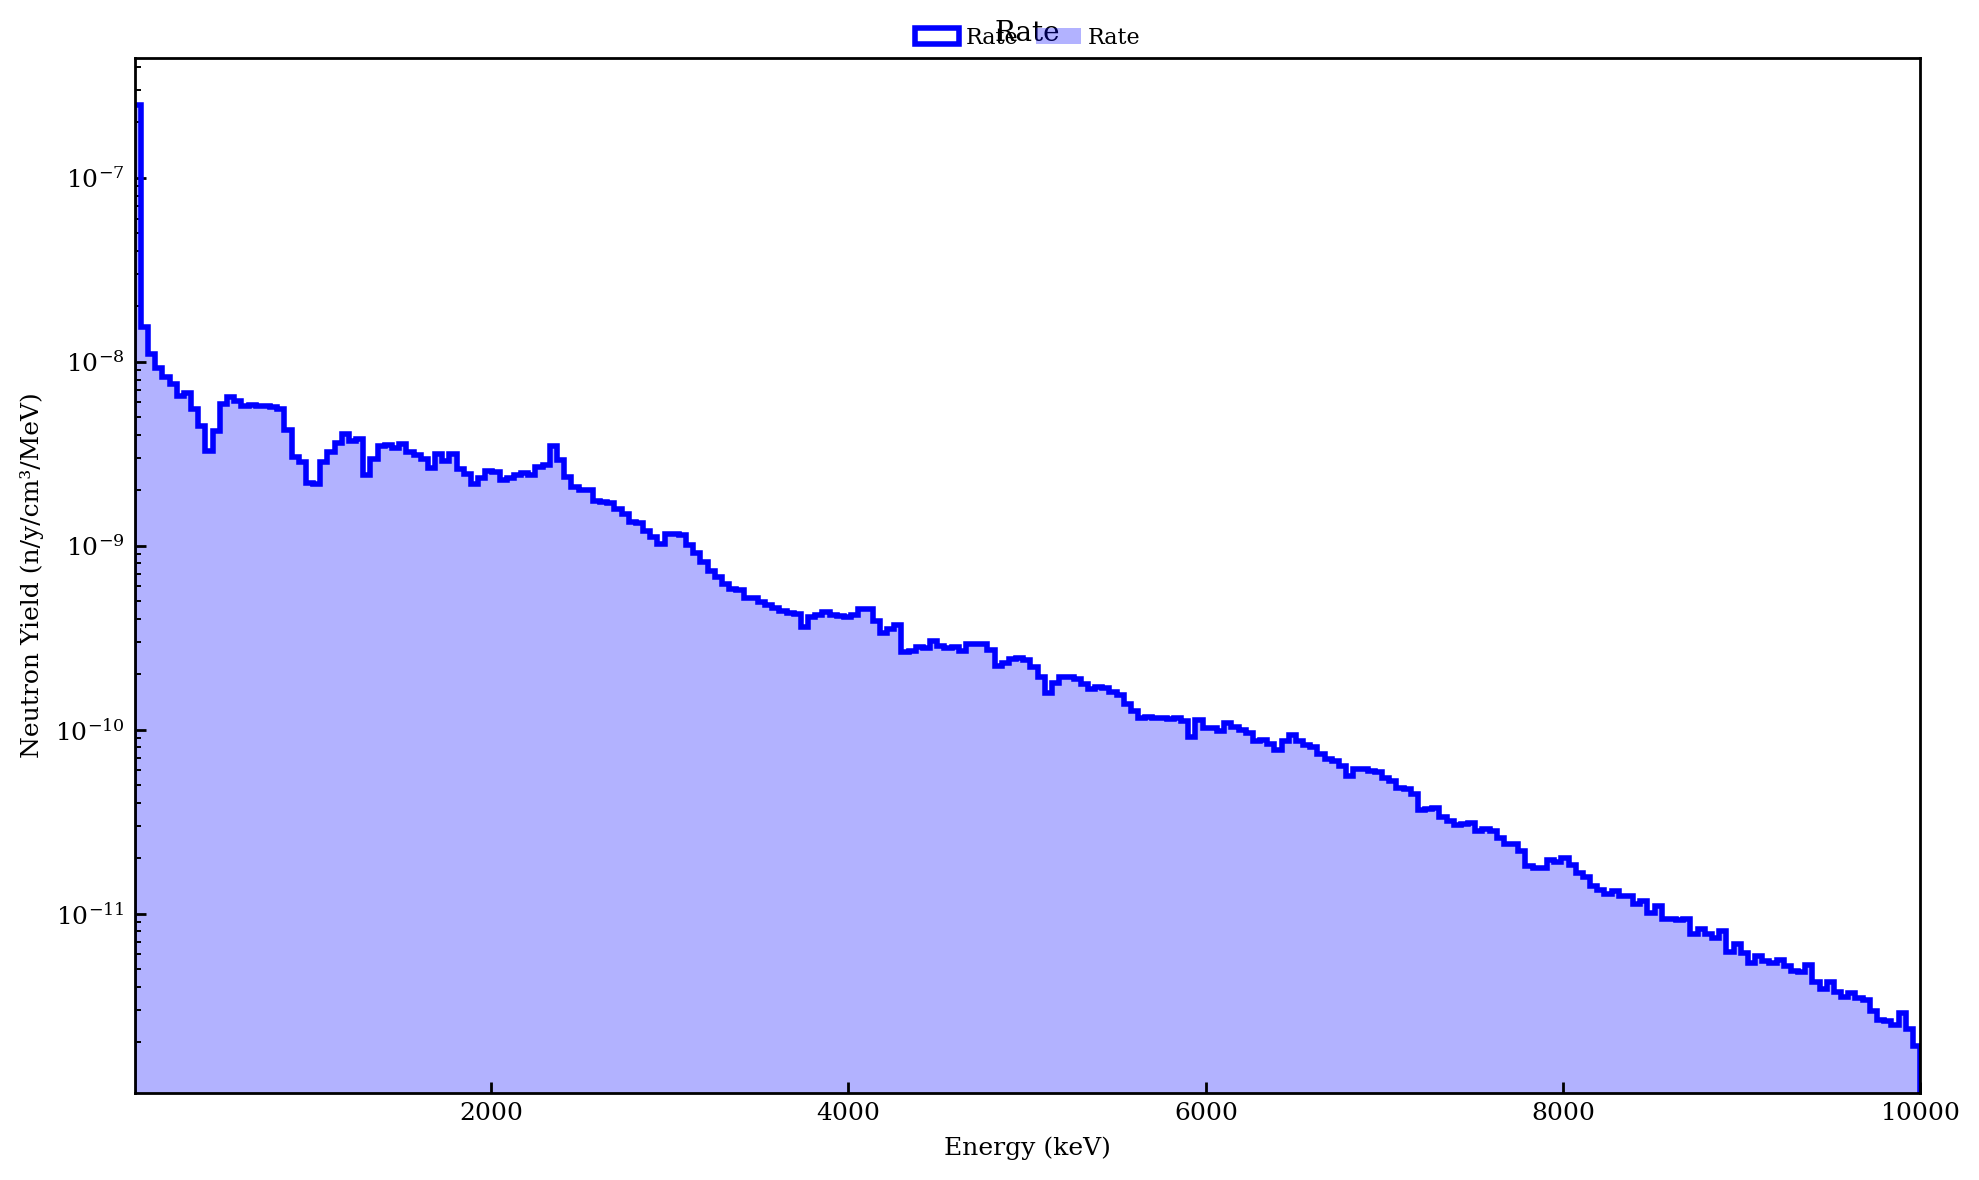

In [69]:
plt.figure(figsize=(10, 6))
plt.hist(bin_data_comb[1][1][:-1], bins=bin_data_comb[1][1], weights=rate, histtype='step', color='blue', linewidth=2, label='Rate')
plt.hist(bin_data_comb[1][1][:-1], bins=bin_data_comb[1][1], weights=rate, histtype='stepfilled', color='blue', linewidth=2, label='Rate', alpha=0.3)
plt.xlabel('Energy (keV)')
plt.ylabel('Neutron Yield (n/y/cm³/MeV)')
plt.title('Rate')
plt.yscale('log')
#plt.ylim(1e-5, 10)
plt.xlim(5,10000)
plt.legend()
plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Rate_inside_hall.pdf")
plt.show()


In [70]:
# Rock: 1.44997e+10 cm^3
# Concrete: 1.12746e+10 cm^3
# Spawn: 9.85145e+09 cm^3

rock_vol_eff = 1.44997e+10 - 1.12746e+10 
concrete_vol_eff = 1.12746e+10 - 9.85145e+09 

vol = rock_vol_eff + concrete_vol_eff
rate_hall = rate * vol

In [72]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Rates.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            rate_hall = rate_hall, 
            bin_data = bin_data_comb[1][1])
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Rates.npz


/tmp/ipykernel_21661/449439016.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


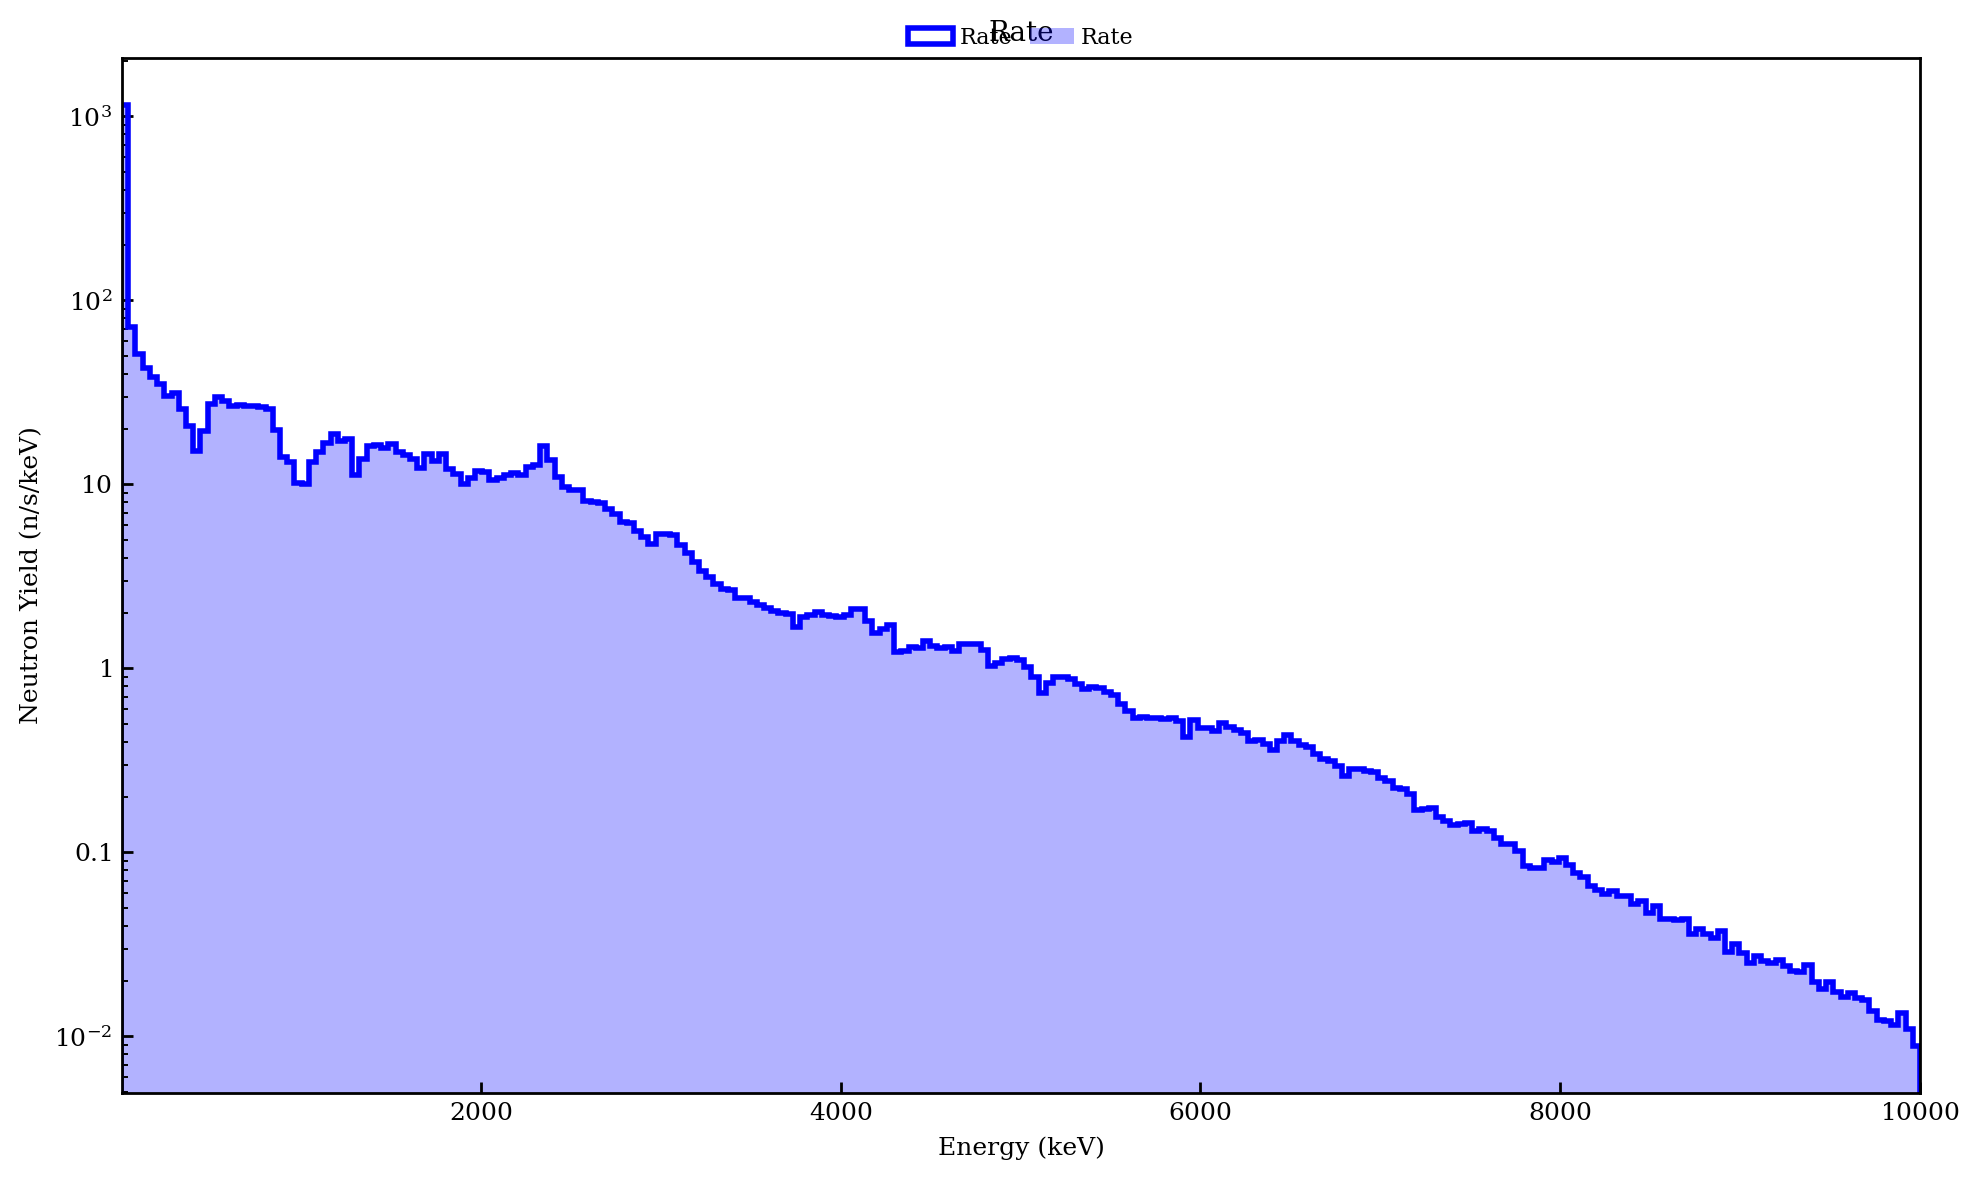

In [73]:

plt.figure(figsize=(10, 6))
plt.hist(bin_data_comb[1][1][:-1], bins=bin_data_comb[1][1], weights=rate_hall, histtype='step', color='blue', linewidth=2, label='Rate')
plt.hist(bin_data_comb[1][1][:-1], bins=bin_data_comb[1][1], weights=rate_hall, histtype='stepfilled', color='blue', linewidth=2, label='Rate', alpha=0.3)
plt.xlabel('Energy (keV)')
plt.ylabel('Neutron Yield (n/s/keV)')
plt.title('Rate')
plt.yscale('log')
#plt.ylim(1e-2, 2e15)
plt.xlim(5,10000)
plt.legend()
plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Rate_inside_hall.pdf")
plt.show()


In [41]:
sum(rate_hall)

np.float64(2565.9195583475307)

# Usefull plots for energy distribution


In [157]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "EnergyDist" 


In [158]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Concrete/EnergyDistributions_Volumes_log.npz"
hist_vals_list_c_log = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_c_log = np.load(path, allow_pickle=True)['bin_edges_list']
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Rock/EnergyDistributions_Volumes_log.npz"
hist_vals_list_r_log = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_r_log = np.load(path, allow_pickle=True)['bin_edges_list']

path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Concrete/EnergyDistributions_Volumes_lin.npz"
hist_vals_list_c_lin = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_c_lin = np.load(path, allow_pickle=True)['bin_edges_list']
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/Rock/EnergyDistributions_Volumes_lin.npz"
hist_vals_list_r_lin = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list_r_lin = np.load(path, allow_pickle=True)['bin_edges_list']

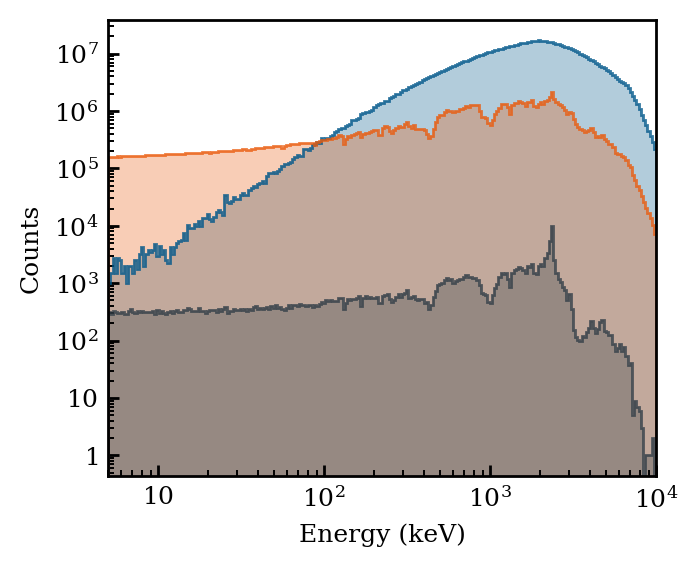

In [159]:
 

vals_data = [hist_vals_list_c_log[0], hist_vals_list_c_log[3], hist_vals_list_r_log[3]]
bin_data = [bin_edges_list_c_log[0], bin_edges_list_c_log[3], bin_edges_list_r_log[3]]
labels = ['Simulated Neutrons', 'Neutrons entering the hall from the concrete', 'Neutrons entering the hall from the rock']

lin_data = [hist_vals_list_c_lin[0], hist_vals_list_c_lin[3], hist_vals_list_r_lin[3]]

#axs_flat = axs.flat  # Flatten the 2D array of axes

col = ['lapis', 'orange', 'graphit']

for i in range(len(vals_data)):
    plt.hist(bin_data[i][:-1], bins=bin_data[i], weights=vals_data[i],
            histtype='step', color=xps.colors[col[i]],
            label=f'{labels[i]} ({sum(lin_data[i]):.2e} counts)', alpha=0.8)
    plt.hist(bin_data[i][:-1], bins=bin_data[i], weights=vals_data[i],
            histtype='stepfilled', color=xps.colors[col[i]], alpha=0.3)


plt.yscale('log')
plt.xscale('log') if i%2 == 0 else plt.xscale('linear')
plt.xlim(5, 10000)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_Counts_sep.png")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_Counts_sep.pdf")
plt.show()

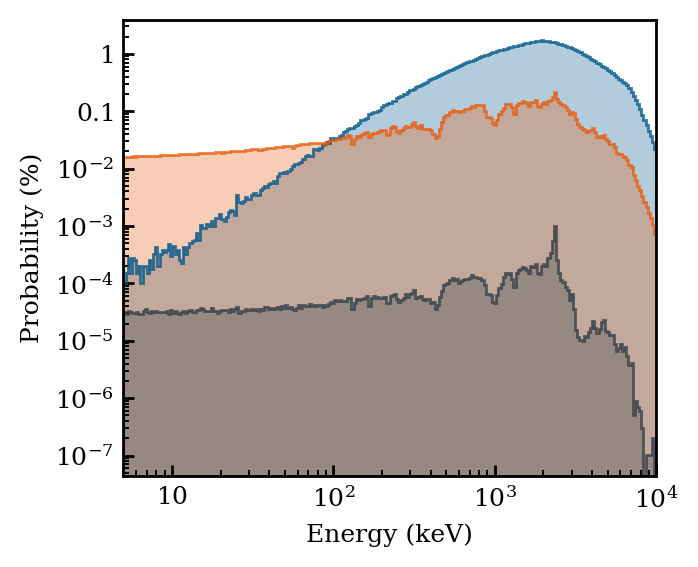

In [160]:


rock_norm = sum(hist_vals_list_r_lin[0])
concrete_norm = sum(hist_vals_list_c_lin[0])

vals_data_norm = [hist_vals_list_c_log[0]/concrete_norm, hist_vals_list_c_log[3]/concrete_norm, hist_vals_list_r_log[3]/rock_norm]
bin_data_norm = [bin_edges_list_c_log[0], bin_edges_list_c_log[3], bin_edges_list_r_log[3]]
labels = ['Simulated Neutrons', 'Neutrons entering the hall from the concrete', 'Neutrons entering the hall from the rock']
lin_data_norm = [hist_vals_list_c_lin[0]/concrete_norm, hist_vals_list_c_lin[3]/concrete_norm, hist_vals_list_r_lin[3]/rock_norm]

#axs_flat = axs.flat  # Flatten the 2D array of axes

for i in range(len(vals_data_norm)):
    plt.hist(bin_data_norm[i][:-1], bins=bin_data_norm[i], weights=vals_data_norm[i]*100,
            histtype='step', color=xps.colors[col[i]],
            label=f'{labels[i]} ({sum(lin_data_norm[i])*100:.2f} %)', alpha=0.8)
    plt.hist(bin_data_norm[i][:-1], bins=bin_data_norm[i], weights=vals_data_norm[i]*100,
            histtype='stepfilled', color=xps.colors[col[i]], alpha=0.3)

plt.yscale('log')
plt.xscale('log')
plt.xlim(5, 10000)
plt.xlabel('Energy (keV)')
plt.ylabel('Probability (%)')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_prob_sep.png")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_prob_sep.pdf")
plt.show()

In [161]:
vals_data_comb = [vals_data_norm[0], 1/3*vals_data_norm[1] + 2/3 * vals_data_norm[2]]
lin_data_comb = [lin_data_norm[0], 1/3*lin_data_norm[1] + 2/3 * lin_data_norm[2]]

bin_data_comb = [bin_data_norm[0], bin_data_norm[1]]

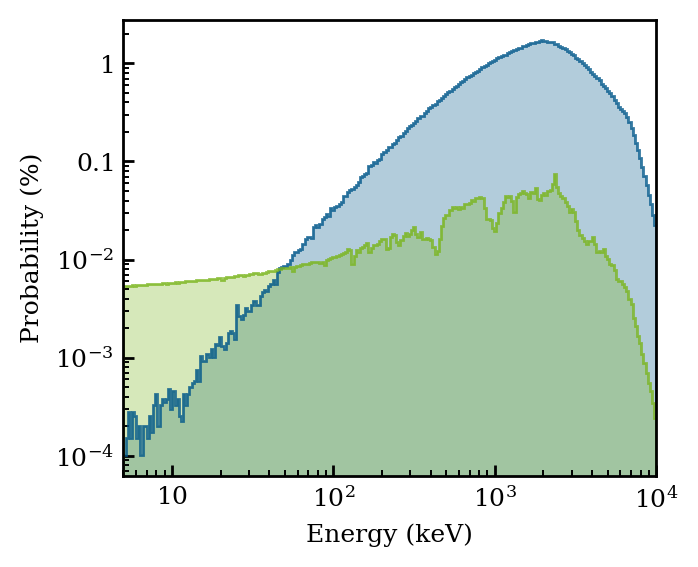

In [162]:


labels = ['Simulated Neutrons', 'Neutrons entering the hall from either volume',]

plt.hist(bin_data_comb[0][:-1], bins=bin_data_comb[0], weights=vals_data_comb[0]*100,
        histtype='step', color=xps.colors[col[0]],
        label=f'{labels[0]} ({sum(lin_data_comb[0])* 100:.2f} %)', alpha=0.8)
plt.hist(bin_data_comb[0][:-1], bins=bin_data_comb[0], weights=vals_data_comb[0]*100,
        histtype='stepfilled', color=xps.colors[col[0]], alpha=0.3)


plt.hist(bin_data_comb[1][:-1], bins=bin_data_comb[1], weights=vals_data_comb[1]*100,
        histtype='step', color=xps.colors['apfelgruen'],
        label=f'{labels[1]} ({sum(lin_data_comb[1])* 100:.2f} %)', alpha=0.8)
plt.hist(bin_data_comb[1][:-1], bins=bin_data_comb[1], weights=vals_data_comb[1]*100,
        histtype='stepfilled', color=xps.colors['apfelgruen'], alpha=0.3)

plt.yscale('log')
plt.xscale('log') 
plt.xlim(5, 10000)
plt.xlabel('Energy (keV)')
plt.ylabel('Probability (%)')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_prob_comb.png")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_prob_comb.pdf")
plt.show()

In [163]:
used_rate = np.loadtxt('/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/RadiogenicNeutronDistribution.txt', skiprows=2)

R0 = 137.375 * sum(used_rate[:,1])

# Rock: 1.44997e+10 cm^3
# Concrete: 1.12746e+10 cm^3
# Spawn: 9.85145e+09 cm^3

rock_vol_eff = 1.44997e+10 - 1.12746e+10 
concrete_vol_eff = 1.12746e+10 - 9.85145e+09 

vol = rock_vol_eff + concrete_vol_eff


rate = vals_data_comb[1] * R0 #/ (v_rock + v_concrete)
rate = rate/(365 * 24 * 3600 )
rate = rate * vol


lin_rate = lin_data_comb[1] * R0 #/ (v_rock + v_concrete)
lin_rate = lin_rate/(365 * 24 * 3600 )
lin_rate = lin_rate * vol

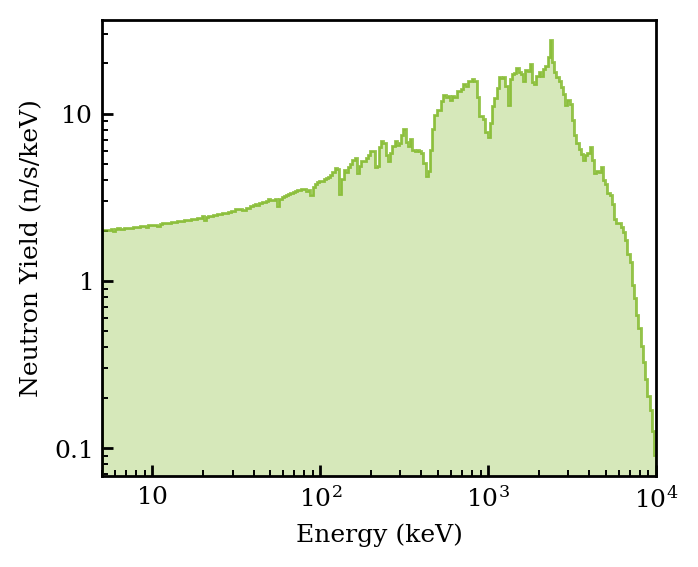

In [164]:

plt.hist(bin_data_comb[1][:-1], bins=bin_data_comb[1], weights=rate,
        histtype='step', color=xps.colors['apfelgruen'],
        label=f'Rate ({sum(lin_rate):.2e} n/s/keV)', alpha=0.8)
plt.hist(bin_data_comb[1][:-1], bins=bin_data_comb[1], weights=rate,
    histtype='stepfilled', color=xps.colors['apfelgruen'], alpha=0.3)

plt.yscale('log')
plt.xscale('log') 
plt.xlim(5, 10000)
plt.xlabel('Energy (keV)')
plt.ylabel('Neutron Yield (n/s/keV)')
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_Rate_hall.png")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/Neutron_Rate_hall.pdf")
plt.show()

In [131]:
cut1 = 250
cut2 = 5000

# Verwende separate Masken für Bin-Zentren und Bin-Kanten
bin_centers = (bin_data_norm[2][:-1] + bin_data_norm[2][1:]) / 2
mask_bins = (bin_centers >= cut1) & (bin_centers <= cut2)  # Länge 250
mask_edges = (bin_data_norm[2] >= cut1) & (bin_data_norm[2] <= cut2)  # Länge 251

bin_data_norm_cut = bin_data_norm[2][mask_edges]  # Bin edges (251)
vals_data_norm_cut = vals_data_norm[2][mask_bins]  # Histogram values (250)

# Fix file reading and data loading
with open("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Crosssections/Literature/O16_n,el.txt") as f:
    lines = (line for line in f if not line.lstrip().startswith(("//", "#")))
    data = np.loadtxt(lines, skiprows=0, usecols=(0, 1), unpack=True)

data = data[0] * 1e3, data[1]  

mask = (data[0] < cut2) & (data[0] > cut1)
data_cut = data[0][mask], data[1][mask]

In [147]:
xps.colors

{'graphit': '#333F48',
 'orange': '#EA5B0D',
 'cassis': '#AF0078',
 'lapis': '#00578A',
 'cyan': '#009DD1',
 'ozean': '#006E89',
 'tuerkis': '#008E96',
 'apfelgruen': '#7AB51D',
 'peridot': '#B1C800',
 'red': '#b22234',
 'yellow': '#FFC72C',
 'darkgreen': '#265c3d'}

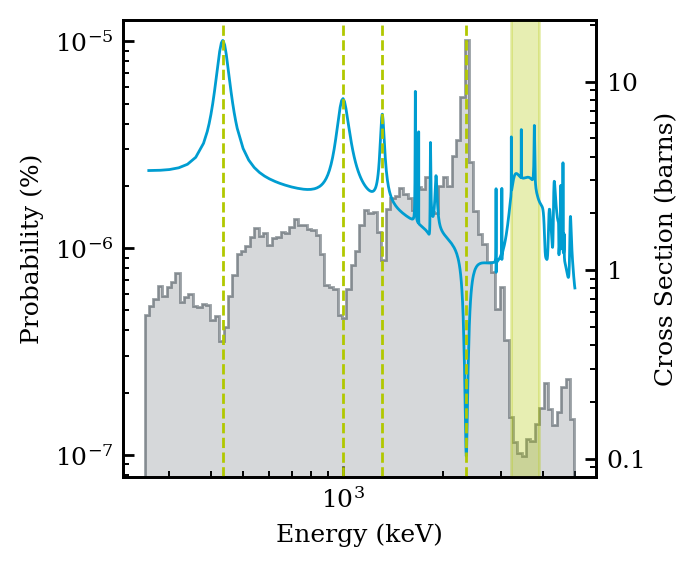

In [156]:
# ...existing code...

#Nächster Hochpunkt (x, y): 0.434 16.5208
#Nächster Hochpunkt (x, y): 1.0 8.12579
#Nächster Hochpunkt (x, y): 1.313 6.71468
#Nächster Tiefpunkt (x, y): 2.35 0.103172

# Erstelle die erste y-Achse (links)
fig, ax1 = plt.subplots()

ax1.hist(bin_data_norm_cut[:-1], bins=bin_data_norm_cut, weights=vals_data_norm_cut,
        histtype='step', color=xps.colors['graphit'],
         alpha=0.5, label='Neutron probability')
ax1.hist(bin_data_norm_cut[:-1], bins=bin_data_norm_cut, weights=vals_data_norm_cut,
    histtype='stepfilled', color=xps.colors['graphit'], alpha=0.2)

ax1.set_yscale('log')
ax1.set_xscale('log') 
ax1.set_xlabel('Energy (keV)')
ax1.set_ylabel('Probability (%)')
ax1.tick_params(axis='y')

# Erstelle die zweite y-Achse (rechts)
ax2 = ax1.twinx()
ax2.plot(data_cut[0], data_cut[1], color=xps.colors['cyan'], 
         label='O16(n,el) Literature')
ax2.set_ylabel('Cross Section (barns)')
ax2.tick_params(axis='y')
ax2.set_yscale('log')

# Bereiche markieren
plt.axvline(434, color=xps.colors['peridot'], linestyle='--')
plt.axvline(1000, color=xps.colors['peridot'], linestyle='--')
plt.axvline(1313, color=xps.colors['peridot'], linestyle='--')
plt.axvline(2350, color=xps.colors['peridot'], linestyle='--')
plt.axvspan(3200, 3900, color=xps.colors['peridot'], alpha=0.3)

plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/cross_sec_comp.png")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/cross_sec_comp.pdf")
plt.show()

# Plots für dicke

## Laden von Dateien

In [22]:
data_path = "/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron"
path_Version = "4_7e82d44"
path_Material = "EnergyDist" 
path_length = "Rock"


min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 250 files matching pattern 'Rock' in '/home/b/bkoberg/AGW_LowRad/data_sim/XeSim_Neutron/4_7e82d44/EnergyDist/Rock/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [53]:
num = 250
uproot_files = uproot_files[:num]

In [54]:
arr = uproot.dask(uproot_files, filter_name=uproot.open(uproot_files[0]).keys(), allow_missing=True, step_size="110MB")
arr['type_pri_id'] = ak.flatten(arr['type_pri_id'])

arr = arr[arr['type_pri_id'] == 2112]
arr


dask.awkward<getitem, npartitions=11500>

In [23]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [24]:
data_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data'
if not os.path.exists(f'{data_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{data_path}/{path_Version}/{path_Material}/{path_length}')

FORCE_OVERWRITE = False

## Meta-Daten und Tabellen für IDs

In [17]:
file = data_files[0]  # Use the first file for demonstration
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

NameError: name 'data_files' is not defined

In [ ]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [18]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [19]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## probability of distance

In [79]:
df = da.to_dataframe(arr[['Save_desc', 'xp_pri']])

df_norm = da.to_dataframe(arr['xp_pri'])

df_cut = df[df['Save_desc'].str.contains('CountPhysicalVolume')]

# wall at x = 1000, found out by looking at Save_x, all are 1000

In [80]:
x_diff = 1000-df_cut['xp_pri']

In [63]:
with ProgressBar():
    laenge = len(df_norm)

[########################################] | 100% Completed | 454.16 s


In [64]:
laenge, 1/laenge

(993071755, 1.00697658045868e-09)

In [81]:
# Bin edges from 0 to 1500 with 100 bins
bin_edges = np.linspace(500, 1500, 100)

# Compute histogram (as Dask, then compute to get numpy arrays)
hist_values, _ = dh.histogram(x_diff, bins=bin_edges)
with ProgressBar():
    hist_values = hist_values.compute()


[########################################] | 100% Completed | 22m 52s


In [82]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/dist_distribution_rock.npz"
if not os.path.exists(path) or FORCE_OVERWRITE:
    print(f"Speichere: {path}")
    np.savez(path, 
            hist_values=hist_values, 
            bin_edges=bin_edges,
            laenge=laenge)
else:
    print(f"Datei bereits vorhanden, überspringe: {path}")

Speichere: /home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Rock/dist_distribution_rock.npz


### Laden und fitten

In [48]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Rock/dist_distribution_rock.npz"
hist_values_r = np.load(path)["hist_values"]
bin_edges_r = np.load(path)["bin_edges"]
laenge_r = np.load(path)["laenge"]

path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/EnergyDist/Concrete/dist_distribution_concrete.npz"
hist_values_c = np.load(path)["hist_values"]
bin_edges_c = np.load(path)["bin_edges"]
laenge_c = np.load(path)["laenge"]

In [49]:
y_err_r = np.sqrt(hist_values_r) / laenge_r
y_err_c = np.sqrt(hist_values_c) / laenge_c

hist_values_r = hist_values_r / laenge_r
hist_values_c = hist_values_c / laenge_c

bin_centers_r = (bin_edges_r[:-1] + bin_edges_r[1:]) / 2
bin_centers_c = (bin_edges_c[:-1] + bin_edges_c[1:]) / 2

In [50]:
def expo(x, A, lamb):
    return A * np.exp(-x / lamb)

least_squares_r = LeastSquares(bin_centers_r, hist_values_r, y_err_r, expo)
m_r = Minuit(least_squares_r, A=1e-4, lamb=100)

m_r.migrad()  # finds minimum of least_squares function
m_r.hesse() 

# Alle Parameter auf einmal
val = {}
for param in m_r.parameters:
    val[param] = ufloat(m_r.values[param], m_r.errors[param])
    print(f"{param} = {val[param]:.6f}")

A = 0.003483+/-0.000022
lamb = 122.948158+/-0.150723


In [56]:
count_vol_probv = val['A'] * unumpy.exp(-1.5 *1000 / val['lamb']) * 100
count_vol_probv

1.7516403590005947e-06+/-2.844118682105403e-08

In [54]:
halbwerts = val['lamb'] * np.log(2) 
halbwerts

85.22116883364822+/-0.1044735305505192

In [28]:
# ...existing code...

# Definiere den Trennpunkt als Variable
split_point = 200

# Erstelle Masken für die beiden Bereiche
mask_c_1 = bin_centers_c <= split_point
mask_c_2 = bin_centers_c > split_point

# Fit für Concrete - Bereich 1 (bis split_point)
least_squares_c_1 = LeastSquares(bin_centers_c[mask_c_1], hist_values_c[mask_c_1], y_err_c[mask_c_1], expo)
m_c_1 = Minuit(least_squares_c_1, A=1e-4, lamb=100)
m_c_1.migrad()
m_c_1.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.614e+05 (χ²/ndof = 4246.2)│              Nfcn = 87               │
│ EDM = 5.95e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │ 8.9428e-3 │ 0.0011e-3 │            │            │         │         │       │
│ 1 │ lamb │  125.225  │   0.021   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬─────────────────────────┐
│      │           A        lamb │
├──────┼─────────────────────────┤
│    A │    1.26e-12 -18.8323e-9 │
│ lamb │ -18.8323e-9     0.00044 │
└──────┴─────────────────────────┘

In [29]:
# Fit für Concrete - Bereich 2 (ab split_point)
least_squares_c_2 = LeastSquares(bin_centers_c[mask_c_2], hist_values_c[mask_c_2], y_err_c[mask_c_2], expo)
m_c_2 = Minuit(least_squares_c_2, A=1e-5, lamb=200)
m_c_2.migrad()
m_c_2.hesse()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5376 (χ²/ndof = 94.3)      │              Nfcn = 172              │
│ EDM = 2.84e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │ 16.040e-3 │ 0.013e-3  │            │            │         │         │       │
│ 1 │ lamb │  89.137   │   0.022   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬───────────────────────┐
│      │          A       lamb │
├──────┼───────────────────────┤
│    A │   1.63e-10 -271.60e-9 │
│ lamb │ -271.60e-9    0.00048 │
└──────┴───────────────────────┘

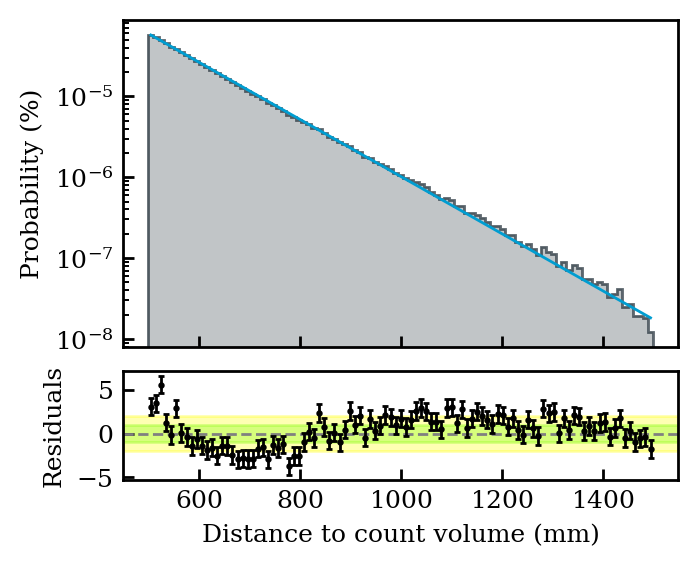

Rock Fit: χ²/ndof = 3.53


In [30]:
# ...existing code...

from matplotlib import gridspec

# Berechne Fit und Residuals für Rock
x_r = np.linspace(bin_edges_r[0], bin_edges_r[-1], 1000)
y_r = expo(bin_centers_r, m_r.values['A'], m_r.values['lamb'])
residuals_r = (hist_values_r - y_r)/y_err_r

# Create a figure with a gridspec layout
fig = plt.figure()
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0, figure = fig)

# Create the main subplots
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Main plot - Histogram und Fit
ax1.hist(bin_edges_r[:-1], bins=bin_edges_r, weights=hist_values_r, 
         histtype='step', color=xps.colors['graphit'], alpha=0.8, label='Rock Data')
ax1.hist(bin_edges_r[:-1], bins=bin_edges_r, weights=hist_values_r,
         color=xps.colors['graphit'], histtype='stepfilled', alpha=0.3)

ax1.plot(bin_centers_r, y_r, color=xps.colors['cyan'],
         label=f'Fit: A={m_r.values["A"]:.2e}, λ={m_r.values["lamb"]:.2f} mm')

# Fit info für Legend
fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_r.fval:.1f} / {m_r.ndof:.0f} = {m_r.fmin.reduced_chi2:.1f}",
]

ax1.set_ylabel('Probability (%)')
ax1.set_yscale('log')

# Residuals plot
ax2.axhline(0, color="gray", lw=1, linestyle="--")
ax2.errorbar(bin_centers_r, residuals_r, yerr=1, fmt="ok", markersize=1.3)
ax2.axhspan(2, -2, color="yellow", alpha=0.3)
ax2.axhspan(1, -1, color="lawngreen", alpha=0.3)

ax2.set_xlabel('Distance to count volume (mm)')
ax2.set_ylabel('Residuals')

# Remove x-axis labels from top plot
ax1.tick_params(labelbottom=False)


plt.savefig(f"{pictures_path}/{path_Version}/{path_Material}/Neutron_Prob_Distance_rock.png")
plt.savefig(f"{pictures_path}/{path_Version}/{path_Material}/Neutron_Prob_Distance_rock.pdf")
plt.show()

print(f'Rock Fit: χ²/ndof = {m_r.fmin.reduced_chi2:.2f}')

In [8]:


plt.hist(bin_edges_c[:-1], bins=bin_edges_c, weights=hist_values_c, histtype='step',color=xps.colors['orange'])
plt.hist(bin_edges_c[:-1], bins=bin_edges_c, weights=hist_values_c,color=xps.colors['orange'], histtype='stepfilled', alpha=0.3)


plt.xlabel('Distance to count volume (mm)')
plt.ylabel('Probability (%)')
plt.yscale('log')
plt.savefig(f"{pictures_path}/{path_Version}/{path_Material}/Neutron_Prob_Distance_conc.png")
plt.savefig(f"{pictures_path}/{path_Version}/{path_Material}/Neutron_Prob_Distance_conc.pdf")
plt.show()

print('10⁻⁹ ist das niedrigste da 1/laenge ungefähr 10⁻⁹ ist')

NameError: name 'plt' is not defined